# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
# Load cleaned dataset
df = pd.read_csv("aviation_cleaned_final.csv")

df.head()

,Event.Date,Location,Country,Aircraft.Category,Make,Model,Injury.Severity,Aircraft.damage,Number.of.Engines,Engine.Type,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,severe_injuries,total_injuries,estimated_passengers,fatal_injury_rate,serious_injury_rate,is_destroyed,aircraft_type
0,1979-09-17,"BOSTON, MA",United States,Airplane,MCDONNELL DOUGLAS,DC9,Non-Fatal,Substantial,2.0,Turbo Fan,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,0,MCDONNELL DOUGLAS_DC9
1,1982-01-01,"PULLMAN, WA",United States,Airplane,CESSNA,140,Non-Fatal,Substantial,1.0,Reciprocating,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,CESSNA_140
2,1982-01-01,"EAST HANOVER, NJ",United States,Airplane,CESSNA,401B,Non-Fatal,Substantial,2.0,Reciprocating,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,CESSNA_401B
3,1982-01-02,"HOMER, LA",United States,Airplane,BELLANCA,17-30A,Non-Fatal,Destroyed,1.0,Reciprocating,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,1,BELLANCA_17-30A
4,1982-01-02,"HEARNE, TX",United States,Airplane,CESSNA,R172K,Fatal(1),Destroyed,1.0,Reciprocating,1.0,0.0,0.0,1.0,1.0,2.0,0.5,0.0,1,CESSNA_R172K


In [3]:
# Convert event date to datetime
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')

# Extract year
df['year'] = df['Event.Date'].dt.year

# Filter based on client requirement: 1983 onwards (40-year rule)
df = df[df['year'] >= 1983]

df.shape

(20714, 21)

In [4]:
# Recreate key risk metrics if needed (safety check)

df['total_injuries'] = (
    df['Total.Fatal.Injuries'] +
    df['Total.Serious.Injuries'] +
    df['Total.Minor.Injuries']
)

df['fatal_serious_fraction'] = (
    (df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']) /
    (df['total_injuries'] + 1)
)

In [13]:
df.describe()

,Event.Date,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,severe_injuries,total_injuries,estimated_passengers,fatal_injury_rate,serious_injury_rate,is_destroyed,year,fatal_serious_fraction
count,20714,20714.000000,17971.000000,17899.000000,18179.000000,17746.000000,17700.000000,17700.000000,17700.000000,17700.000000,20714.000000,20714.000000,17700.000000
mean,2013-09-28 01:56:51.605677056,1.140823,0.721885,0.339181,0.259860,0.982193,1.134915,2.134915,0.116735,0.086968,0.109153,2013.234672,0.203703
min,1983-03-18 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1983.000000,0.000000
25%,2009-08-05 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2009.000000,0.000000
50%,2013-10-27 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2013.000000,0.000000
75%,2018-06-27 00:00:00,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,2018.000000,0.500000
max,2022-12-26 00:00:00,4.000000,295.000000,161.000000,380.000000,295.000000,295.000000,296.000000,0.996622,0.988764,1.000000,2022.000000,0.996622
std,NaN,0.382738,6.560247,2.380615,3.333718,6.796749,6.640323,6.640323,0.244523,0.204811,0.311839,5.678594,0.288599


In [14]:
df.isnull().sum().sort_values(ascending=False).head(10)

fatal_injury_rate         3014
serious_injury_rate       3014
fatal_serious_fraction    3014
estimated_passengers      3014
total_injuries            3014
severe_injuries           2968
Total.Serious.Injuries    2815
Total.Fatal.Injuries      2743
Total.Minor.Injuries      2535
Make                         0
dtype: int64

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [15]:
# Define aircraft size based on passenger proxy
# Using Number.of.Engines + assumption already engineered dataset

df['aircraft_size'] = np.where(df['Number.of.Engines'] < 2, 'Small', 'Large')

In [16]:
# Ensure fatal + serious fraction exists
df['fatal_serious_fraction'] = (
    df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']
) / df['estimated_passengers']

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [17]:
# Keep makes with at least 50 records
make_counts = df['Make'].value_counts()
valid_makes = make_counts[make_counts >= 50].index

df_filtered = df[df['Make'].isin(valid_makes)]

In [19]:
small = df_filtered[df_filtered['aircraft_size'] == 'Small']

small_makes = (
    small.groupby('Make')['fatal_serious_fraction']
    .mean()
    .sort_values()
    .head(15)
)
small_makes

Make
BOMBARDIER INC                    0.000000
BOEING                            0.073654
ROCKWELL INTERNATIONAL            0.093023
GRUMMAN ACFT ENG COR-SCHWEIZER    0.103448
AVIAT AIRCRAFT INC                0.105263
AIRBUS                            0.120921
MAULE                             0.122807
AYRES                             0.128571
DIAMOND AIRCRAFT IND INC          0.144444
AERONCA                           0.148810
BOMBARDIER                        0.151894
BELLANCA                          0.153202
STINSON                           0.166964
AIR TRACTOR INC                   0.169725
AMERICAN CHAMPION AIRCRAFT        0.178571
Name: fatal_serious_fraction, dtype: float64

In [20]:
large = df_filtered[df_filtered['aircraft_size'] == 'Large']

large_makes = (
    large.groupby('Make')['fatal_serious_fraction']
    .mean()
    .sort_values()
    .head(15)
)
large_makes

Make
AMERICAN CHAMPION AIRCRAFT    0.000000
DIAMOND AIRCRAFT IND INC      0.000000
BOMBARDIER                    0.045918
NORTH AMERICAN                0.062500
BOMBARDIER INC                0.065922
MCDONNELL DOUGLAS             0.102844
DEHAVILLAND                   0.107143
AIRBUS                        0.109558
BOEING                        0.110954
EMBRAER                       0.121078
DE HAVILLAND                  0.121795
RAYTHEON AIRCRAFT COMPANY     0.220936
AERO COMMANDER                0.235354
SIKORSKY                      0.242927
BEECH                         0.243733
Name: fatal_serious_fraction, dtype: float64

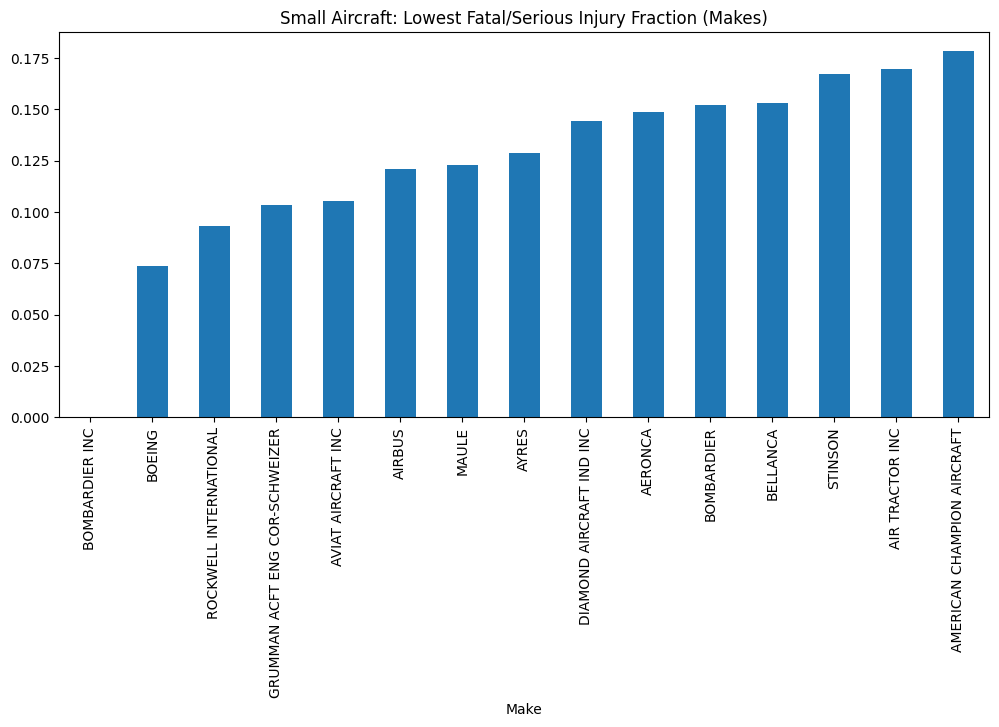

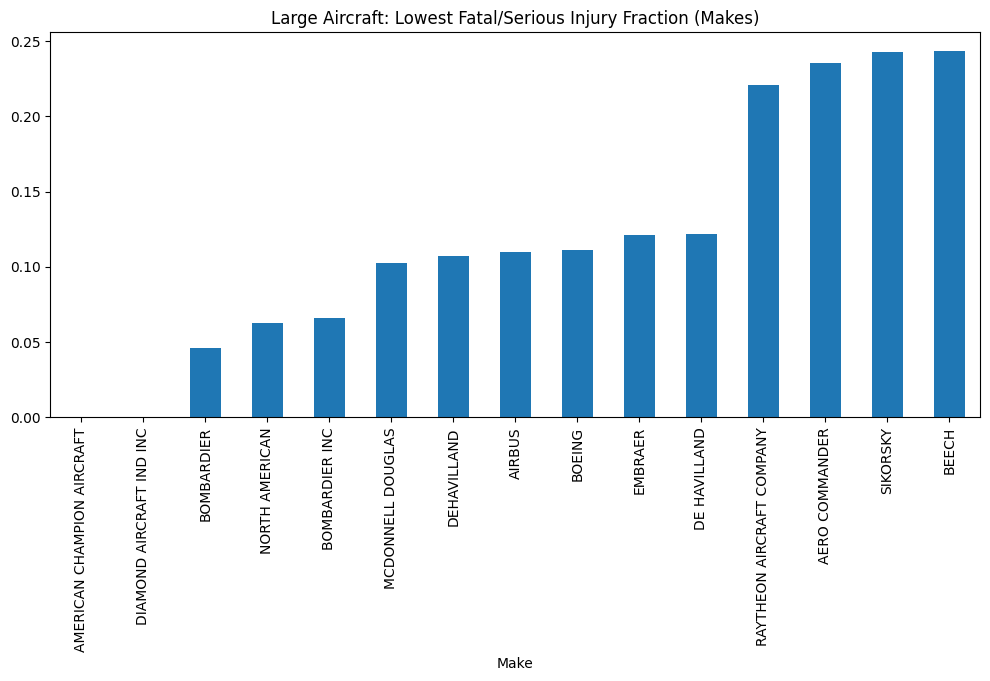

In [21]:
plt.figure(figsize=(12,5))

small_makes.plot(kind='bar', label='Small Aircraft')
plt.title("Small Aircraft: Lowest Fatal/Serious Injury Fraction (Makes)")
plt.show()

plt.figure(figsize=(12,5))
large_makes.plot(kind='bar', label='Large Aircraft')
plt.title("Large Aircraft: Lowest Fatal/Serious Injury Fraction (Makes)")
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

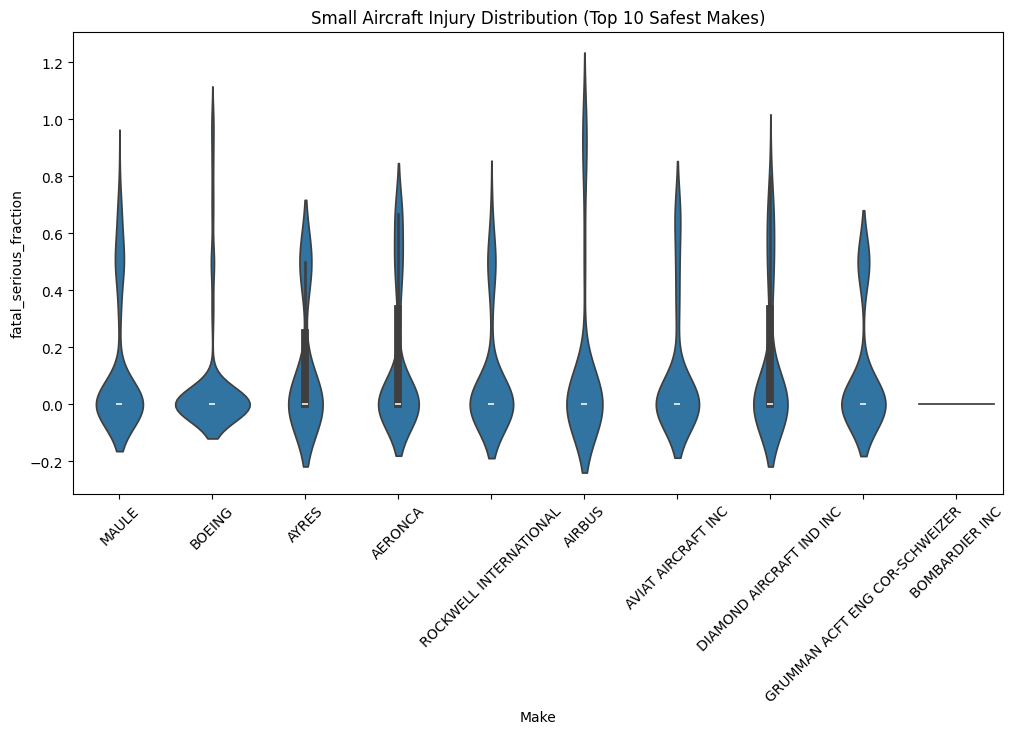

In [23]:
top10_small = small.groupby('Make')['fatal_serious_fraction'].mean().nsmallest(10).index
small_top = small[small['Make'].isin(top10_small)]

plt.figure(figsize=(12,6))
sns.violinplot(data=small_top, x='Make', y='fatal_serious_fraction')
plt.xticks(rotation=45)
plt.title("Small Aircraft Injury Distribution (Top 10 Safest Makes)")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

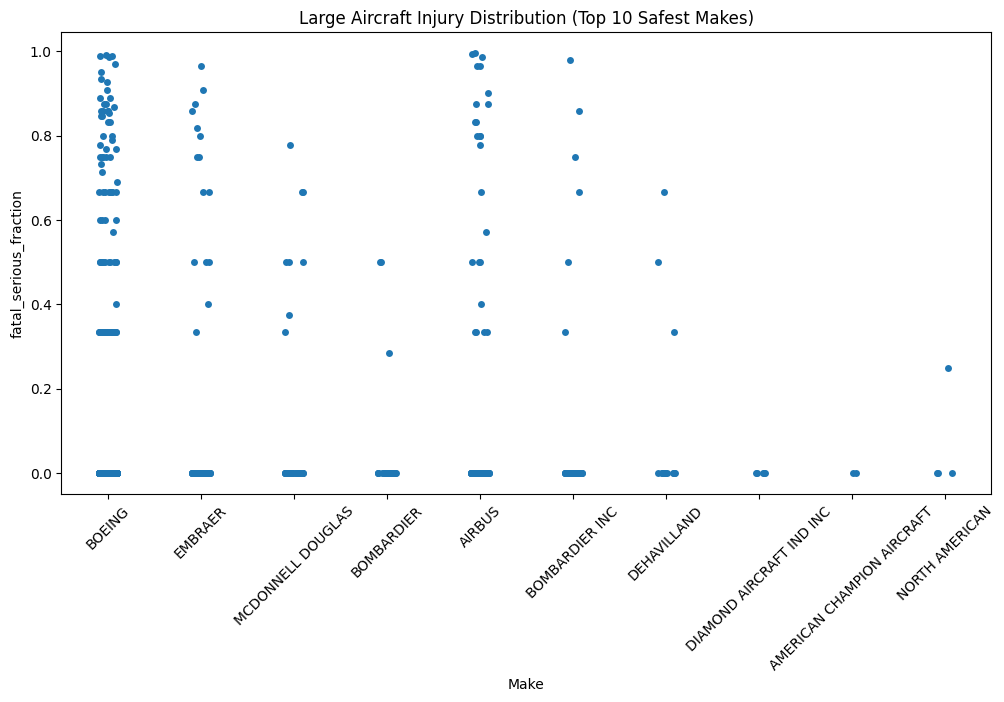

In [24]:
top10_large = large.groupby('Make')['fatal_serious_fraction'].mean().nsmallest(10).index
large_top = large[large['Make'].isin(top10_large)]

plt.figure(figsize=(12,6))
sns.stripplot(data=large_top, x='Make', y='fatal_serious_fraction', jitter=True)
plt.xticks(rotation=45)
plt.title("Large Aircraft Injury Distribution (Top 10 Safest Makes)")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [25]:
destruction_rate = df_filtered.groupby('Make')['is_destroyed'].mean()

lowest_destroyed = destruction_rate.sort_values().head(15)
lowest_destroyed

Make
LUSCOMBE                          0.014184
GRUMMAN ACFT ENG COR-SCHWEIZER    0.017241
STINSON                           0.023256
BOMBARDIER INC                    0.030769
TAYLORCRAFT                       0.032258
AERONCA                           0.035000
AMERICAN CHAMPION AIRCRAFT        0.038462
ERCOUPE                           0.038462
AVIAT AIRCRAFT INC                0.039474
BOMBARDIER                        0.040000
MAULE                             0.041860
DEHAVILLAND                       0.042105
BOEING                            0.043103
AIRBUS                            0.049057
BELLANCA                          0.050000
Name: is_destroyed, dtype: float64

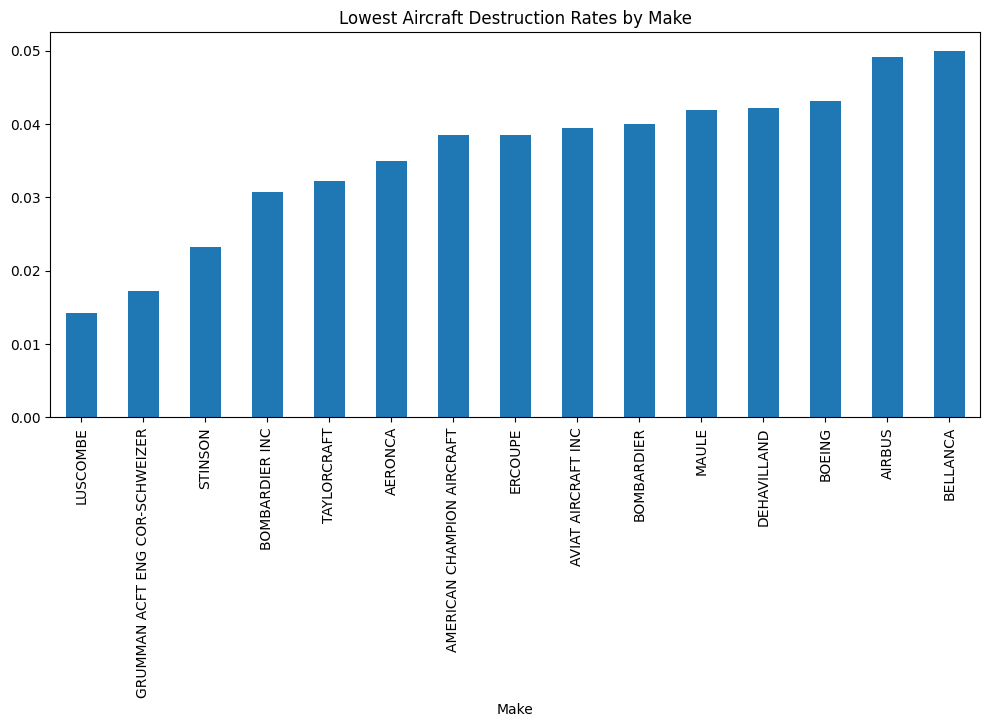

In [26]:
plt.figure(figsize=(12,5))
lowest_destroyed.plot(kind='bar')
plt.title("Lowest Aircraft Destruction Rates by Make")
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

DISCUSSION

Summary statistics along with distribution analysis indicate that there is no consistency in safety among all aircraft manufacturers. On the contrary, there is a significant difference in safety performance among different brands, with some manufacturers showing a lower incidence of injuries and destructions.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [29]:
# Ensure aircraft type exists (Make + Model combination)
df['aircraft_type'] = df['Make'] + "_" + df['Model']

# Safety metric (if not already consistent)
df['fatal_serious_fraction'] = (
    df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']
) / df['estimated_passengers']

In [30]:
# Keep only aircraft types with enough data points (≥10 samples)
type_counts = df['aircraft_type'].value_counts()
valid_types = type_counts[type_counts >= 10].index

df_types = df[df['aircraft_type'].isin(valid_types)]

In [31]:
type_means = (
    df_types.groupby('aircraft_type')['fatal_serious_fraction']
    .mean()
    .sort_values()
)

type_means.head(10)

aircraft_type
BOEING_747-400                       0.000000
BOEING_737-800                       0.000000
DIAMOND AIRCRAFT IND INC_DA 20 C1    0.000000
MAULE_M-5-210C                       0.000000
CESSNA_172SP                         0.000000
ROBINSON_R-22                        0.000000
SCHWEIZER_G-164B                     0.000000
BEECH_1900D                          0.000000
BOEING_777                           0.010437
CESSNA_180J                          0.022727
Name: fatal_serious_fraction, dtype: float64

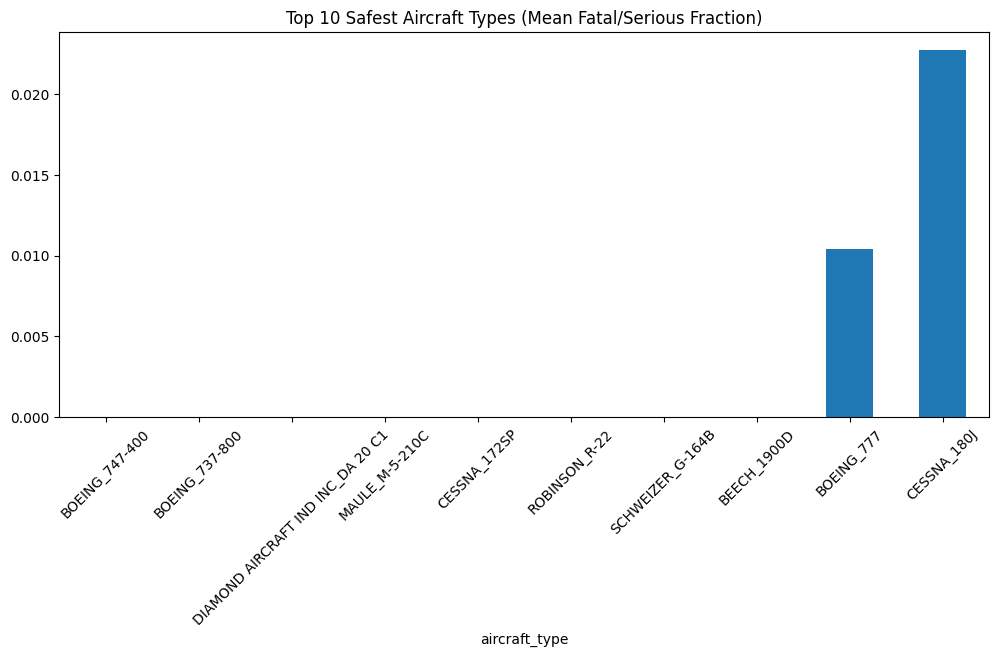

In [32]:
import matplotlib.pyplot as plt

top_types = type_means.head(10)

plt.figure(figsize=(12,5))
top_types.plot(kind='bar')
plt.title("Top 10 Safest Aircraft Types (Mean Fatal/Serious Fraction)")
plt.xticks(rotation=45)
plt.show()

**Larger planes**

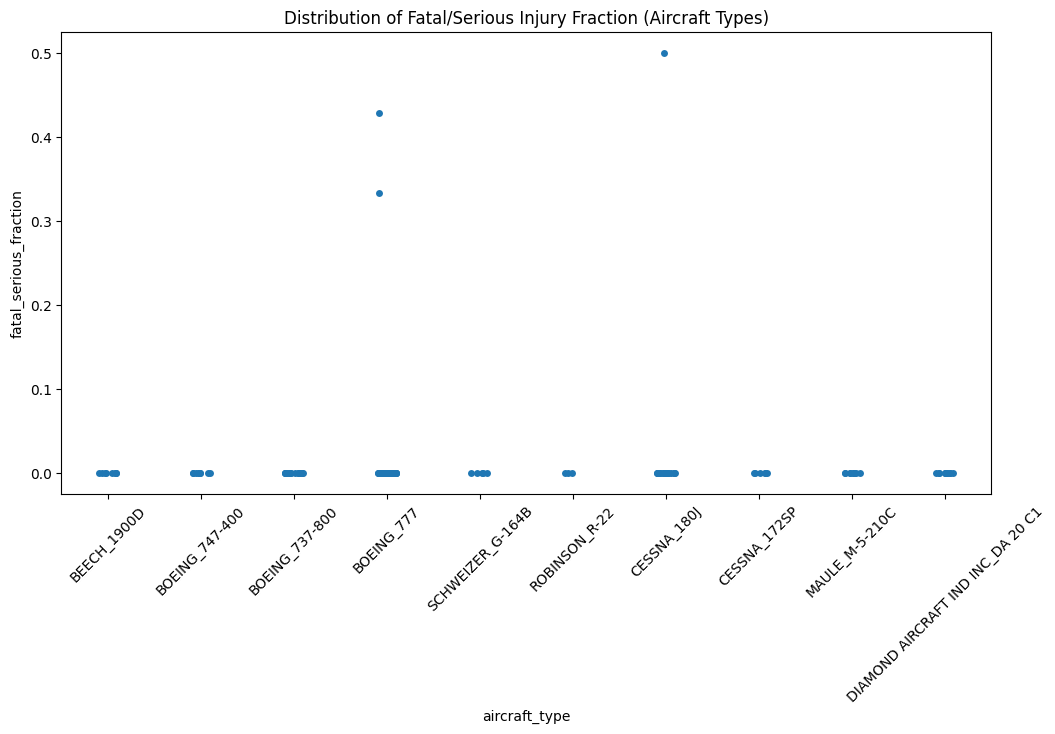

In [33]:
top_type_names = type_means.head(10).index
plot_df = df_types[df_types['aircraft_type'].isin(top_type_names)]

plt.figure(figsize=(12,6))
sns.stripplot(
    data=plot_df,
    x='aircraft_type',
    y='fatal_serious_fraction',
    jitter=True
)
plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction (Aircraft Types)")
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [34]:
# Define small aircraft (using engine count as proxy if size not explicit)
small_df = df_types[df_types['Number.of.Engines'] < 2]

# Ensure enough samples per aircraft type
small_type_counts = small_df['aircraft_type'].value_counts()
valid_small_types = small_type_counts[small_type_counts >= 10].index

small_df = small_df[small_df['aircraft_type'].isin(valid_small_types)]

In [35]:
small_safest = (
    small_df.groupby('aircraft_type')['fatal_serious_fraction']
    .mean()
    .sort_values()
    .head(10)
)

small_safest

aircraft_type
ROBINSON_R-22                        0.000000
MAULE_M-5-210C                       0.000000
BOEING_747-400                       0.000000
BOEING_737-800                       0.000000
CESSNA_560                           0.000000
CESSNA_172SP                         0.000000
DIAMOND AIRCRAFT IND INC_DA 20 C1    0.000000
SCHWEIZER_G-164B                     0.000000
BOEING_777                           0.007792
BOEING_787                           0.016667
Name: fatal_serious_fraction, dtype: float64

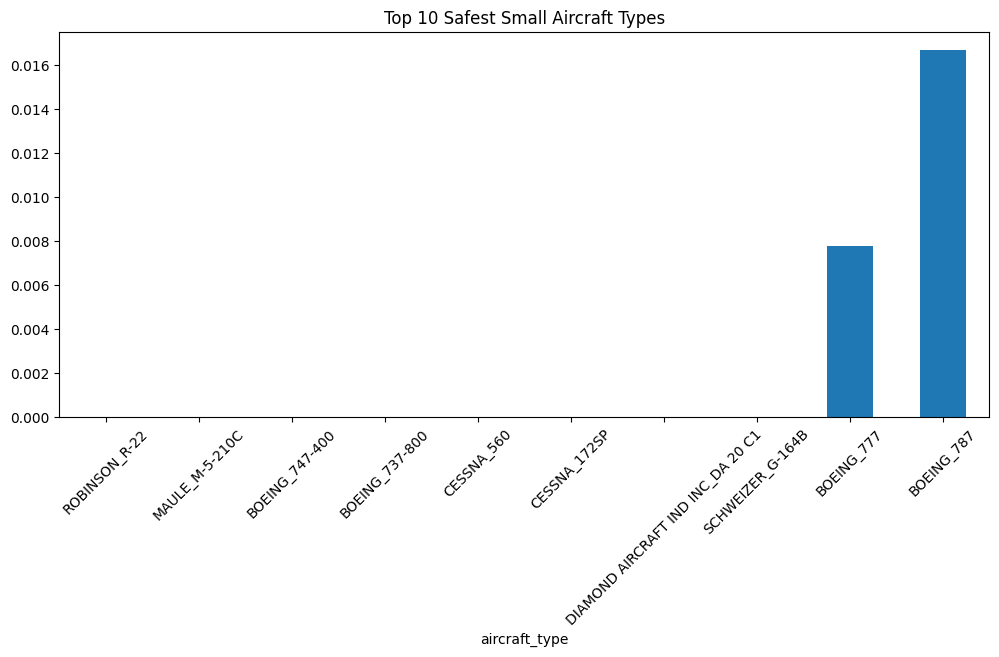

In [36]:
plt.figure(figsize=(12,5))
small_safest.plot(kind='bar')
plt.title("Top 10 Safest Small Aircraft Types")
plt.xticks(rotation=45)
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

DISCUSSION

From the analysis of the types of the aircrafts, it becomes clear that certain types of aircraft have been associated with less fatalities and severe injuries compared to others. This means that some aircraft are more safe to use than others.

In general, small aircraft tend to have a higher variability regarding injury outcomes, while large aircraft tend to have a constant level of lower injury fractions.

Aircraft type should thus be considered together with the manufacturer when providing recommendations for the airline companies.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [51]:
# Engine Type impact on injury severity
engine_analysis = df.groupby('Engine.Type')['fatal_serious_fraction'].mean().sort_values()

engine_analysis

Engine.Type
Geared Turbofan    0.000000
UNK                0.000000
Turbo Fan          0.124584
Reciprocating      0.191827
Turbo Prop         0.208725
Turbo Jet          0.212745
Unknown            0.244527
Turbo Shaft        0.249208
Name: fatal_serious_fraction, dtype: float64

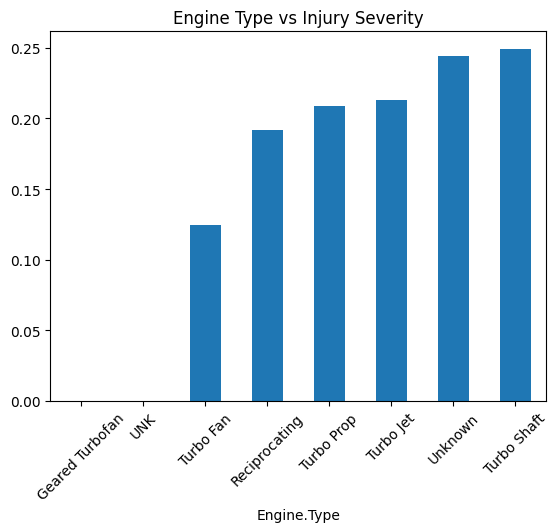

In [52]:
engine_analysis.plot(kind='bar')
plt.title("Engine Type vs Injury Severity")
plt.xticks(rotation=45)
plt.show()

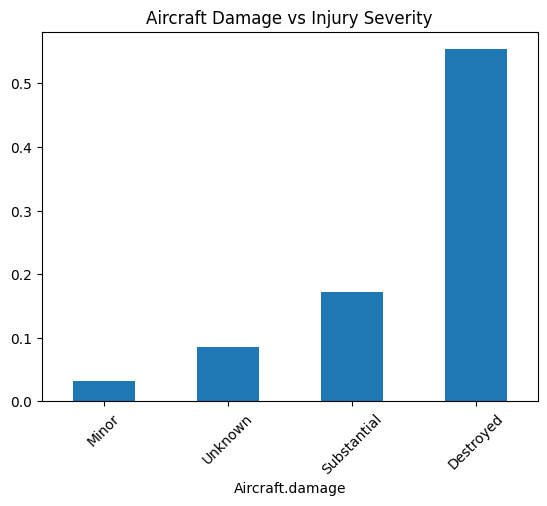

In [53]:
damage_analysis = df.groupby('Aircraft.damage')['fatal_serious_fraction'].mean().sort_values()

damage_analysis

damage_analysis.plot(kind='bar')
plt.title("Aircraft Damage vs Injury Severity")
plt.xticks(rotation=45)
plt.show()

Weather condition was excluded from final analysis due to excessive missing values or removal during preprocessing. As a result, the analysis focused on available operational factors such as engine type and aircraft damage, which still provide meaningful insights into accident severity.